<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v2/blob/master/STM32_HW_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11 · STM32 Hardware Comparison — All 4 Student Candidates

**Purpose:** Deploy all four student candidates on the NUCLEO-N657X0-Q and
compare real hardware performance. Extends the 2×2 controlled design from
notebook 10 to actual hardware — isolating architecture and initialization
effects on STM32 latency and quantized accuracy.

## Experimental design

| | Scratch | Pretrained |
|---|---|---|
| **MobileNetV2** | nb 06 | nb 07 |
| **MobileNetV3** | nb 08 | nb 09 |

**Two hardware claims this notebook answers:**

**Claim 1 — Architecture effect on hardware** (initialization held constant):
- V2 scratch vs V3 scratch → does architecture affect STM32 latency/accuracy?
- V2 pretrained vs V3 pretrained → consistent under both init conditions?

**Claim 2 — Initialization effect on hardware** (architecture held constant):
- V2 scratch vs V2 pretrained → does pretraining affect quantized accuracy on STM32?
- V3 scratch vs V3 pretrained → same question for V3 architecture?

## Board
NUCLEO-N657X0-Q — STM32N657X0H3Q, Cortex-M55 @ 800MHz, 4.2MB SRAM


In [17]:
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ utils loaded from Drive


In [18]:
import os, time
import numpy as np
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders, manifest_paths, VWWDataset, get_eval_transform
from utils.models  import (
    MobileNetV2_Scratch, MobileNetV2_Pretrained,
    MobileNetV3_Scratch, MobileNetV3_Pretrained,
    count_params, model_size_mb,
)
from utils.train import setup_device, evaluate

device = setup_device(seed=41)


Device: cuda


In [19]:
prepare_dataset()
_, val_loader = get_loaders(batch_size=64)


1/4 Download
✅ VWW archive already downloaded
2/4 Extract
✅ VWW already extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests
Train: 7000 | Val: 1500 | Batch: 64


In [20]:
SAVE_DIR = "/content/drive/My Drive/Colab Notebooks"


In [21]:
# ── Checkpoint configuration ─────────────────────────────────────────
# Update seed_XX values after running notebooks 06–09

STUDENT_CKPTS = {
    "MobileNetV2 (scratch)":          (MobileNetV2_Scratch,    f"{SAVE_DIR}/mobilenetv2_baseline_seed_41.pth",  "V2_scratch"),
    "MobileNetV2 (pretrained)":       (MobileNetV2_Pretrained, f"{SAVE_DIR}/mobilenetv2_pretrained_seed_52.pth","V2_pretrained"),
    "MobileNetV3-Small (scratch)":    (MobileNetV3_Scratch,    f"{SAVE_DIR}/mobilenetv3_scratch_seed_41.pth",   "V3_scratch"),
    "MobileNetV3-Small (pretrained)": (MobileNetV3_Pretrained, f"{SAVE_DIR}/mobilenetv3_baseline_seed_63.pth",  "V3_pretrained"),
}


In [22]:
# ── Load all 4 models and print baseline metrics ─────────────────────
models = {}
for name, (fn, ckpt, tag) in STUDENT_CKPTS.items():
    if not os.path.exists(ckpt):
        print(f"⚠️  Missing checkpoint: {name} — {ckpt}")
        continue
    m = fn().to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    models[name] = (m, tag)

    acc  = evaluate(m, val_loader, device)
    tp,_ = count_params(m)
    size = model_size_mb(m)
    print(f"{name:42s}  val={acc*100:.2f}%  params={tp/1e6:.3f}M  size={size:.2f}MB")


MobileNetV2 (scratch)                       val=78.80%  params=0.152M  size=0.68MB
MobileNetV2 (pretrained)                    val=76.73%  params=2.226M  size=9.15MB
MobileNetV3-Small (scratch)                 val=77.53%  params=1.520M  size=6.22MB
MobileNetV3-Small (pretrained)              val=77.40%  params=1.520M  size=6.22MB


In [23]:
!pip -q install onnx onnxruntime onnxscript
import onnx
import onnxruntime as ort
from onnxruntime.quantization import (
    quantize_static, QuantType, QuantFormat, CalibrationDataReader
)
from torch.utils.data import DataLoader
from pathlib import Path

EXPORT_DIR    = Path(f"{SAVE_DIR}/exports"); EXPORT_DIR.mkdir(exist_ok=True)
IMG_SIZE      = 96
CALIB_SAMPLES = 200
EVAL_SAMPLES  = 200

def export_fp32_onnx(model, tag):
    path  = str(EXPORT_DIR / f"vww_{tag}_fp32.onnx")
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    torch.onnx.export(
        model.cpu(), dummy, path,
        input_names=["input"], output_names=["logits"],
        opset_version=18, do_constant_folding=True,
        dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
        dynamo=False,
    )
    onnx.checker.check_model(path)
    model.to(device)
    print(f"  ✅ FP32 ONNX: {path}")
    return path

def collect_arrays(n_calib, n_eval):
    mp       = manifest_paths()
    eval_tf  = get_eval_transform()
    train_ds = VWWDataset(mp["train_person"], mp["train_non_person"], eval_tf)
    val_ds   = VWWDataset(mp["val_person"],   mp["val_non_person"],   eval_tf)
    def collect(ds, n):
        loader = DataLoader(ds, batch_size=1, shuffle=False)
        xs, ys = [], []
        for i, (x, y) in enumerate(loader):
            if i >= n: break
            xs.append(x.numpy().astype("float32")[0])
            ys.append(int(y.item()))
        return np.stack(xs), np.array(ys, dtype="int32")
    calib_x, _     = collect(train_ds, n_calib)
    val_x,   val_y = collect(val_ds,   n_eval)
    return calib_x, val_x, val_y

class CalibReader(CalibrationDataReader):
    def __init__(self, x, name="input"):
        self.x = x; self.name = name; self.i = 0
    def get_next(self):
        if self.i >= len(self.x): return None
        out = {self.name: self.x[self.i:self.i+1]}; self.i += 1; return out
    def rewind(self): self.i = 0

def export_int8_onnx(fp32_path, calib_x, tag):
    path = str(EXPORT_DIR / f"vww_{tag}_int8_qdq.onnx")
    quantize_static(
        model_input=fp32_path, model_output=path,
        calibration_data_reader=CalibReader(calib_x),
        quant_format=QuantFormat.QDQ,
        activation_type=QuantType.QInt8, weight_type=QuantType.QInt8,
        per_channel=True,
    )
    print(f"  ✅ INT8 QDQ ONNX: {path}")
    return path

def onnx_accuracy(onnx_path, val_x, val_y):
    sess     = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
    in_name  = sess.get_inputs()[0].name
    out_name = sess.get_outputs()[0].name
    preds    = [np.argmax(sess.run([out_name], {in_name: val_x[i:i+1]})[0][0])
                for i in range(len(val_x))]
    return round((np.array(preds) == val_y).mean() * 100, 2)

def save_arrays(tag, calib_x, val_x, val_y):
    np.savez(str(EXPORT_DIR / f"vww_{tag}_calib.npz"),  input=calib_x)
    np.savez(str(EXPORT_DIR / f"vww_{tag}_val.npz"),    input=val_x)
    np.savez(str(EXPORT_DIR / f"vww_{tag}_labels.npz"), label=val_y)

def stm32_accuracy(labels_npz, outputs_npz, key="c_outputs_1", num_classes=2):
    y   = np.load(labels_npz)["label"].astype("int64")
    raw = np.load(outputs_npz)[key].reshape(len(y), num_classes)
    acc = (np.argmax(raw, 1) == y).mean() * 100
    print(f"STM32 accuracy: {acc:.2f}%  ({len(y)} samples)")
    return round(acc, 2)


In [24]:
# ── Export all 4 models: FP32 + INT8 ONNX ────────────────────────────
calib_x, val_x, val_y = collect_arrays(CALIB_SAMPLES, EVAL_SAMPLES)

export_results = {}   # tag → {fp32_path, int8_path, fp32_acc, int8_acc}

for name, (m, tag) in models.items():
    print(f"\nExporting: {name}")
    save_arrays(tag, calib_x, val_x, val_y)
    fp32_path = export_fp32_onnx(m, tag)
    int8_path = export_int8_onnx(fp32_path, calib_x, tag)
    fp32_acc  = onnx_accuracy(fp32_path, val_x, val_y)
    int8_acc  = onnx_accuracy(int8_path, val_x, val_y)
    export_results[name] = {
        "tag": tag, "fp32_path": fp32_path, "int8_path": int8_path,
        "fp32_acc": fp32_acc, "int8_acc": int8_acc,
    }
    print(f"  ONNX FP32: {fp32_acc:.2f}%  |  ONNX INT8: {int8_acc:.2f}%")



Exporting: MobileNetV2 (scratch)


/tmp/ipykernel_972/3224815857.py:18: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


  ✅ FP32 ONNX: /content/drive/My Drive/Colab Notebooks/exports/vww_V2_scratch_fp32.onnx


  ✅ INT8 QDQ ONNX: /content/drive/My Drive/Colab Notebooks/exports/vww_V2_scratch_int8_qdq.onnx
  ONNX FP32: 81.50%  |  ONNX INT8: 90.00%

Exporting: MobileNetV2 (pretrained)


  ✅ FP32 ONNX: /content/drive/My Drive/Colab Notebooks/exports/vww_V2_pretrained_fp32.onnx


...

  ✅ FP32 ONNX: /content/drive/My Drive/Colab Notebooks/exports/vww_V3_scratch_fp32.onnx


/usr/local/lib/python3.12/dist-packages/onnxruntime/quantization/base_quantizer.py:222: RuntimeWarning: divide by zero encountered in divide
  quantized_data = np.asarray(bias_data, dtype=np.float64) / np.asarray(bias_scale, dtype=np.float64)


  ✅ INT8 QDQ ONNX: /content/drive/My Drive/Colab Notebooks/exports/vww_V3_scratch_int8_qdq.onnx
  ONNX FP32: 79.50%  |  ONNX INT8: 76.00%

Exporting: MobileNetV3-Small (pretrained)


  ✅ FP32 ONNX: /content/drive/My Drive/Colab Notebooks/exports/vww_V3_pretrained_fp32.onnx


  ✅ INT8 QDQ ONNX: /content/drive/My Drive/Colab Notebooks/exports/vww_V3_pretrained_int8_qdq.onnx
  ONNX FP32: 77.00%  |  ONNX INT8: 81.50%


In [25]:
# ── ONNX Runtime summary ─────────────────────────────────────────────
import pandas as pd

rows = []
for name, (m, tag) in models.items():
    r    = export_results[name]
    acc  = evaluate(m, val_loader, device)
    size = model_size_mb(m)
    rows.append({
        "Model":           name,
        "Architecture":    "MobileNetV2" if "V2" in name else "MobileNetV3-Small",
        "Init":            "Scratch" if "scratch" in name else "Pretrained",
        "Val Acc (%)":     round(acc*100, 2),
        "ONNX FP32 (%)":   r["fp32_acc"],
        "ONNX INT8 (%)":   r["int8_acc"],
        "Quant drop (%)":  round(r["fp32_acc"] - r["int8_acc"], 2),
        "Size FP32 (MB)":  round(size, 2),
        "Size INT8 (MB)":  round(size/4, 2),
    })

df_onnx = pd.DataFrame(rows).set_index("Model")
print("\nONNX Runtime Results")
print(df_onnx.drop(columns=["Architecture","Init"]).to_string())



ONNX Runtime Results
                                Val Acc (%)  ONNX FP32 (%)  ONNX INT8 (%)  Quant drop (%)  Size FP32 (MB)  Size INT8 (MB)
Model                                                                                                                    
MobileNetV2 (scratch)                 78.80           81.5           90.0            -8.5            0.68            0.17
MobileNetV2 (pretrained)              76.73           83.5           86.5            -3.0            9.15            2.29
MobileNetV3-Small (scratch)           77.53           79.5           76.0             3.5            6.22            1.55
MobileNetV3-Small (pretrained)        77.40           77.0           81.5            -4.5            6.22            1.55


## STM32 Deployment Instructions

Run all four models on the NUCLEO-N657X0-Q using X-CUBE-AI.

**For each model:**
1. Open STM32CubeIDE → X-CUBE-AI
2. Import the INT8 QDQ ONNX file from the exports folder
3. Use the corresponding `vww_*_val.npz` as input batch
4. Run validation → note accuracy
5. Check profiling report → note inference latency (ms)
6. Rename output NPZ and score with `stm32_accuracy()` below

**Files to deploy (in exports folder on Drive):**

| Model | ONNX file | Input arrays |
|-------|-----------|-------------|
| MobileNetV2 scratch | `vww_V2_scratch_int8_qdq.onnx` | `vww_V2_scratch_val.npz` |
| MobileNetV2 pretrained | `vww_V2_pretrained_int8_qdq.onnx` | `vww_V2_pretrained_val.npz` |
| MobileNetV3 scratch | `vww_V3_scratch_int8_qdq.onnx` | `vww_V3_scratch_val.npz` |
| MobileNetV3 pretrained | `vww_V3_pretrained_int8_qdq.onnx` | `vww_V3_pretrained_val.npz` |


In [34]:
# ── STM32 results — fill in after all four hardware runs ─────────────

# Score each model after STM32 run:
stm32_accuracy(str(EXPORT_DIR/"vww_V2_scratch_labels.npz"),    "outputs_V2_scratch.npz")
stm32_accuracy(str(EXPORT_DIR/"vww_V2_pretrained_labels.npz"), "outputs_V2_pretrained.npz")
stm32_accuracy(str(EXPORT_DIR/"vww_V3_scratch_labels.npz"),    "outputs_V3_scratch.npz")
stm32_accuracy(str(EXPORT_DIR/"vww_V3_pretrained_labels.npz"), "outputs_V3_pretrained.npz")

# Fill in after hardware runs — None until then
HW_RESULTS = {
    "MobileNetV2 (scratch)": {
        "Architecture": "MobileNetV2", "Init": "Scratch",
        "ONNX INT8 (%)":     export_results["MobileNetV2 (scratch)"]["int8_acc"],
        "STM32 INT8 (%)":    82.5,   # fill after hardware run
        "STM32 Latency (ms)":2.845,   # fill from X-CUBE-AI profiling
        "Size INT8 (MB)":    round(model_size_mb(models["MobileNetV2 (scratch)"][0])/4, 2),
    },
    "MobileNetV2 (pretrained)": {
        "Architecture": "MobileNetV2", "Init": "Pretrained",
        "ONNX INT8 (%)":     export_results["MobileNetV2 (pretrained)"]["int8_acc"],
        "STM32 INT8 (%)":    83.5,
        "STM32 Latency (ms)":11.144,
        "Size INT8 (MB)":    round(model_size_mb(models["MobileNetV2 (pretrained)"][0])/4, 2),
    },
    "MobileNetV3-Small (scratch)": {
        "Architecture": "MobileNetV3-Small", "Init": "Scratch",
        "ONNX INT8 (%)":     export_results["MobileNetV3-Small (scratch)"]["int8_acc"],
        "STM32 INT8 (%)":    80.0,
        "STM32 Latency (ms)":8.333,
        "Size INT8 (MB)":    round(model_size_mb(models["MobileNetV3-Small (scratch)"][0])/4, 2),
    },
    "MobileNetV3-Small (pretrained)": {
        "Architecture": "MobileNetV3-Small", "Init": "Pretrained",
        "ONNX INT8 (%)":     export_results["MobileNetV3-Small (pretrained)"]["int8_acc"],
        "STM32 INT8 (%)":    81.5,
        "STM32 Latency (ms)":8.349,
        "Size INT8 (MB)":    round(model_size_mb(models["MobileNetV3-Small (pretrained)"][0])/4, 2),
    },
}

df_hw = pd.DataFrame(HW_RESULTS).T
print("\nSTM32 Hardware Results (fill in STM32 columns after hardware runs)")
print(df_hw.to_string())
print("\n→ Copy HW_RESULTS into notebook 18_Final_Results hardware section")


STM32 accuracy: 82.50%  (200 samples)
STM32 accuracy: 83.50%  (200 samples)
STM32 accuracy: 80.00%  (200 samples)
STM32 accuracy: 81.50%  (200 samples)

STM32 Hardware Results (fill in STM32 columns after hardware runs)
                                     Architecture        Init ONNX INT8 (%) STM32 INT8 (%) STM32 Latency (ms) Size INT8 (MB)
MobileNetV2 (scratch)                 MobileNetV2     Scratch          90.0           82.5              2.845           0.17
MobileNetV2 (pretrained)              MobileNetV2  Pretrained          86.5           83.5             11.144           2.29
MobileNetV3-Small (scratch)     MobileNetV3-Small     Scratch          76.0           80.0              8.333           1.55
MobileNetV3-Small (pretrained)  MobileNetV3-Small  Pretrained          81.5           81.5              8.349           1.55

→ Copy HW_RESULTS into notebook 18_Final_Results hardware section


In [35]:
# ── 2×2 hardware claims — auto-computed after STM32 results filled in ─
if all(HW_RESULTS[m]["STM32 INT8 (%)"] is not None for m in HW_RESULTS):
    print("\n" + "="*65)
    print("Claim 1 — Architecture Effect on STM32 (V2 vs V3)")
    print("="*65)
    scratch_delta = (HW_RESULTS["MobileNetV3-Small (scratch)"]["STM32 INT8 (%)"]
                   - HW_RESULTS["MobileNetV2 (scratch)"]["STM32 INT8 (%)"])
    pt_delta      = (HW_RESULTS["MobileNetV3-Small (pretrained)"]["STM32 INT8 (%)"]
                   - HW_RESULTS["MobileNetV2 (pretrained)"]["STM32 INT8 (%)"])
    print(f"  V3 vs V2 (both scratch):    {scratch_delta:+.2f}%")
    print(f"  V3 vs V2 (both pretrained): {pt_delta:+.2f}%")

    print("\n" + "="*65)
    print("Claim 2 — Initialization Effect on STM32 (Scratch vs Pretrained)")
    print("="*65)
    v2_delta = (HW_RESULTS["MobileNetV2 (pretrained)"]["STM32 INT8 (%)"]
               - HW_RESULTS["MobileNetV2 (scratch)"]["STM32 INT8 (%)"])
    v3_delta = (HW_RESULTS["MobileNetV3-Small (pretrained)"]["STM32 INT8 (%)"]
               - HW_RESULTS["MobileNetV3-Small (scratch)"]["STM32 INT8 (%)"])
    print(f"  Pretrained vs Scratch (V2): {v2_delta:+.2f}%")
    print(f"  Pretrained vs Scratch (V3): {v3_delta:+.2f}%")

    print("\n" + "="*65)
    print("Latency Comparison")
    print("="*65)
    for name, r in HW_RESULTS.items():
        print(f"  {name:42s}  {r['STM32 Latency (ms)']}ms  {r['Size INT8 (MB)']}MB")
else:
    print("Fill in STM32 INT8 (%) and STM32 Latency (ms) in HW_RESULTS to compute claims.")



Claim 1 — Architecture Effect on STM32 (V2 vs V3)
  V3 vs V2 (both scratch):    -2.50%
  V3 vs V2 (both pretrained): -2.00%

Claim 2 — Initialization Effect on STM32 (Scratch vs Pretrained)
  Pretrained vs Scratch (V2): +1.00%
  Pretrained vs Scratch (V3): +1.50%

Latency Comparison
  MobileNetV2 (scratch)                       2.845ms  0.17MB
  MobileNetV2 (pretrained)                    11.144ms  2.29MB
  MobileNetV3-Small (scratch)                 8.333ms  1.55MB
  MobileNetV3-Small (pretrained)              8.349ms  1.55MB


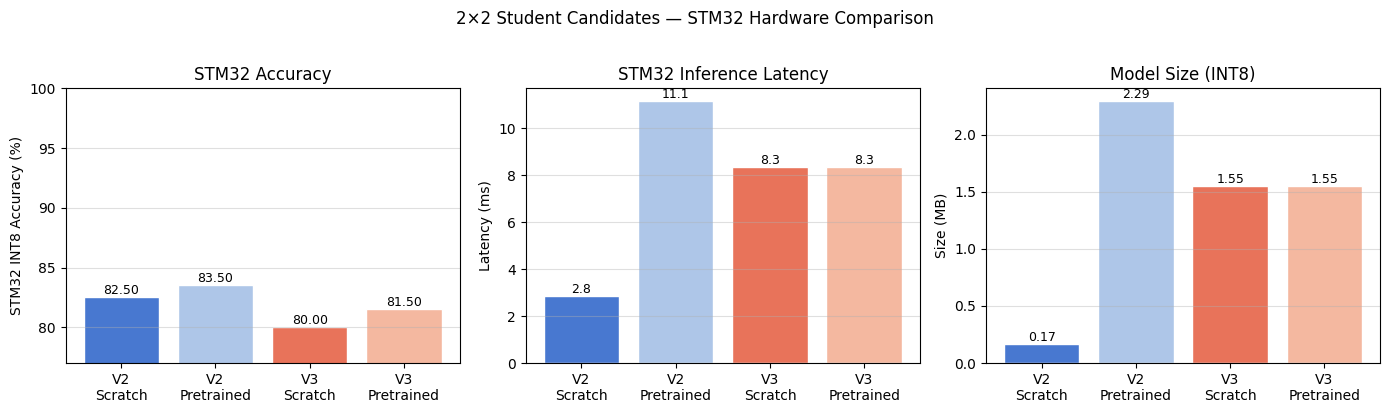

In [36]:
# ── Visualization — runs after STM32 results filled in ───────────────
import matplotlib.pyplot as plt

if all(HW_RESULTS[m]["STM32 INT8 (%)"] is not None for m in HW_RESULTS):
    names   = list(HW_RESULTS.keys())
    short   = ["V2\nScratch", "V2\nPretrained", "V3\nScratch", "V3\nPretrained"]
    colors  = ["#4878D0", "#aec6e8", "#E8735A", "#f4b8a0"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # STM32 INT8 accuracy
    ax = axes[0]
    accs = [HW_RESULTS[m]["STM32 INT8 (%)"] for m in names]
    bars = ax.bar(short, accs, color=colors, edgecolor="white")
    ax.set_ylabel("STM32 INT8 Accuracy (%)"); ax.set_title("STM32 Accuracy")
    ax.set_ylim(min(accs)-3, 100); ax.grid(axis="y", alpha=0.4)
    for b in bars:
        ax.annotate(f"{b.get_height():.2f}",
                   (b.get_x()+b.get_width()/2, b.get_height()),
                   ha="center", va="bottom", fontsize=9)

    # STM32 latency
    ax = axes[1]
    lats = [HW_RESULTS[m]["STM32 Latency (ms)"] for m in names]
    bars = ax.bar(short, lats, color=colors, edgecolor="white")
    ax.set_ylabel("Latency (ms)"); ax.set_title("STM32 Inference Latency")
    ax.grid(axis="y", alpha=0.4)
    for b in bars:
        ax.annotate(f"{b.get_height():.1f}",
                   (b.get_x()+b.get_width()/2, b.get_height()),
                   ha="center", va="bottom", fontsize=9)

    # Model size INT8
    ax = axes[2]
    sizes = [HW_RESULTS[m]["Size INT8 (MB)"] for m in names]
    bars  = ax.bar(short, sizes, color=colors, edgecolor="white")
    ax.set_ylabel("Size (MB)"); ax.set_title("Model Size (INT8)")
    ax.grid(axis="y", alpha=0.4)
    for b in bars:
        ax.annotate(f"{b.get_height():.2f}",
                   (b.get_x()+b.get_width()/2, b.get_height()),
                   ha="center", va="bottom", fontsize=9)

    plt.suptitle("2×2 Student Candidates — STM32 Hardware Comparison", fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("Fill in HW_RESULTS to generate plots.")
